# SaaS Customer Retention Engine  
### Churn Prediction + Segmentation + Explainability

## Business Problem
Customer churn is a critical challenge in SaaS businesses. Retaining existing users is significantly more cost-effective than acquiring new ones.

## Objective
Build a system that:
- Predicts customer churn
- Segments users by risk
- Explains why customers churn
- Recommends retention actions

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
from xgboost import XGBClassifier
import shap
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec4;">Load the DataFrame</span> 
  </h1>
</div>

In [2]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

### Check for any missing values

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Data Cleaning & Preprocessing</span> 
  </h1>
</div>

In [9]:
# We can see TotalCharges data type is object, which is incorrect
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [10]:
target = 'Churn'
# target encoding
target_map = {'No': 0, 'Yes': 1}
df.drop(columns=["customerID"], inplace=True)

df[target] = df[target].map(target_map).astype(int)

In [11]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Data Visualization</span> 
  </h1>
</div>

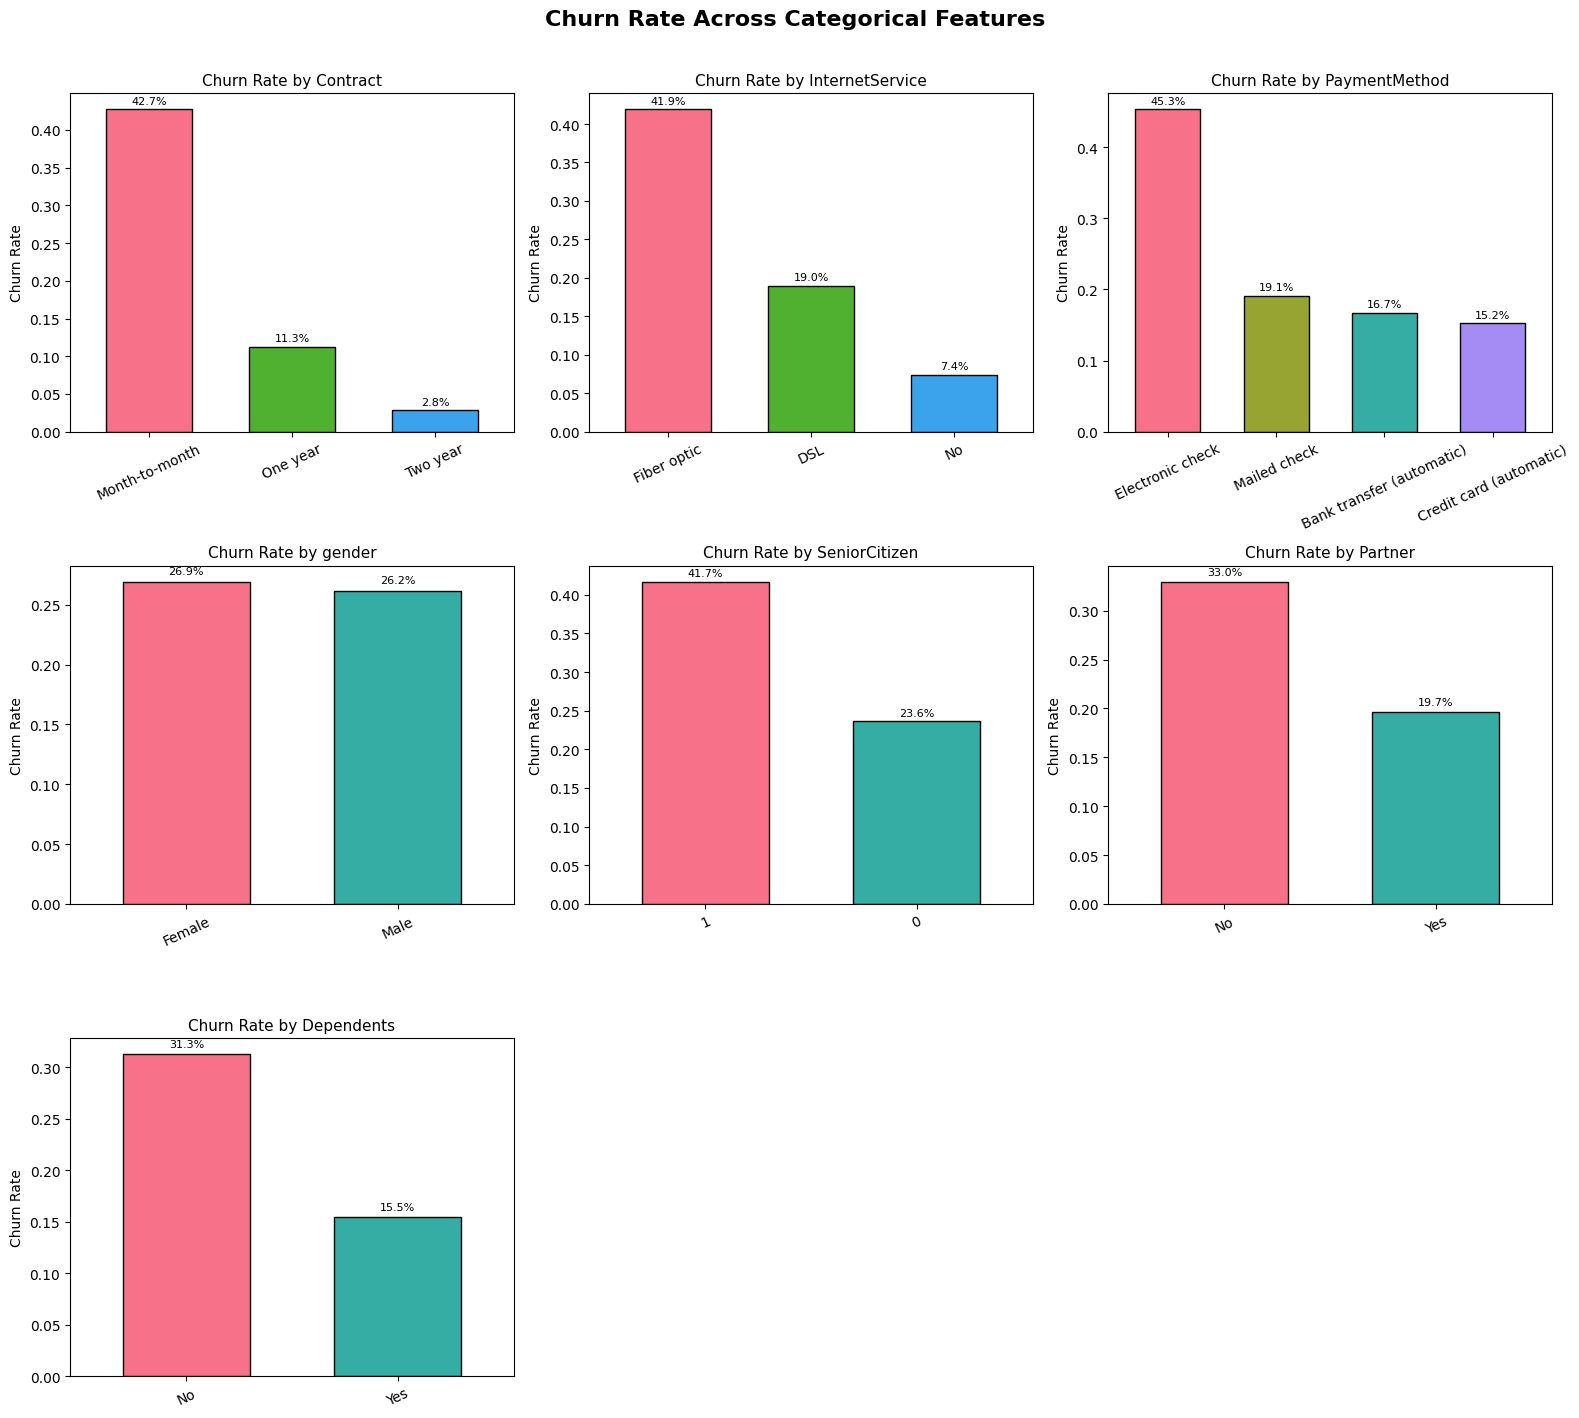

In [12]:
cat_cols = ["Contract","InternetService","PaymentMethod","gender","SeniorCitizen","Partner","Dependents"]
fig, axes = plt.subplots(3, 3, figsize=(16,14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    ct.plot(kind="bar", ax=axes[i], color=sns.color_palette("husl", len(ct)),
            edgecolor="black", width=0.6)
    axes[i].set_title(f"Churn Rate by {col}", fontsize=11)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=8)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Churn Rate Across Categorical Features", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_categorical.png")
plt.show()

### Key findings that the business owner can use for decision making

- Customers on Month-to-month contracts churn at ~42% — far above annual/biennial plans.
- High MonthlyCharges combined with low tenure signals high churn probability.
- Fiber optic internet users churn more than DSL or no-internet users.
- Electronic check payers have the highest churn rate among payment methods.


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Feature Engineering</span> 
  </h1>
</div>

In [13]:
df_model = df.copy()

binary_cols = [c for c in df_model.select_dtypes("object").columns
               if set(df_model[c].unique()) <= {"Yes","No"}]
for c in binary_cols:
    df_model[c] = (df_model[c] == "Yes").astype(int)

# One-hot encode remaining categoricals
df_model = pd.get_dummies(df_model, drop_first=True)

print(f"Features after encoding: {df_model.shape[1]-1}")
df_model.head(4)

Features after encoding: 30


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False


In [14]:
X = df_model.copy()
y = X.pop('Churn')

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=32, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s  = scaler.transform(X_valid)
print(f"Train: {len(X_train)} | Test: {len(X_valid)}")

Train: 4930 | Test: 2113


In [15]:
from sklearn.metrics import classification_report
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),  # 50 instead of 200
    "XGBoost":   XGBClassifier(n_estimators=100, learning_rate=0.03, random_state=42),

}
results = {}
for name, model in models.items():
    Xtr, Xte = (X_train_s, X_valid_s) if "Logistic" in name else (X_train, X_valid)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    auc   = roc_auc_score(y_valid, proba)
    results[name] = {"model":model, "preds":preds, "proba":proba, "auc":auc}
    print(f"\n=== {name} (AUC={auc:.4f}) ===")
    print(classification_report(y_valid, preds, target_names=["No Churn","Churn"]))


=== Logistic Regression (AUC=0.8372) ===
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1552
       Churn       0.51      0.78      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.80      0.74      0.76      2113


=== Random Forest (AUC=0.8217) ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1552
       Churn       0.64      0.48      0.55       561

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113


=== XGBoost (AUC=0.8444) ===
              precision    recall  f1-score   support

    No Churn       0.84      0.92      0.88      1552
       Churn       0.69      0.50      0.58       561

    accuracy                           0.81      2113
   macro avg       0

### XGboost achieves strong discrimination between churn and non-churn customers, enabling proactive intervention.

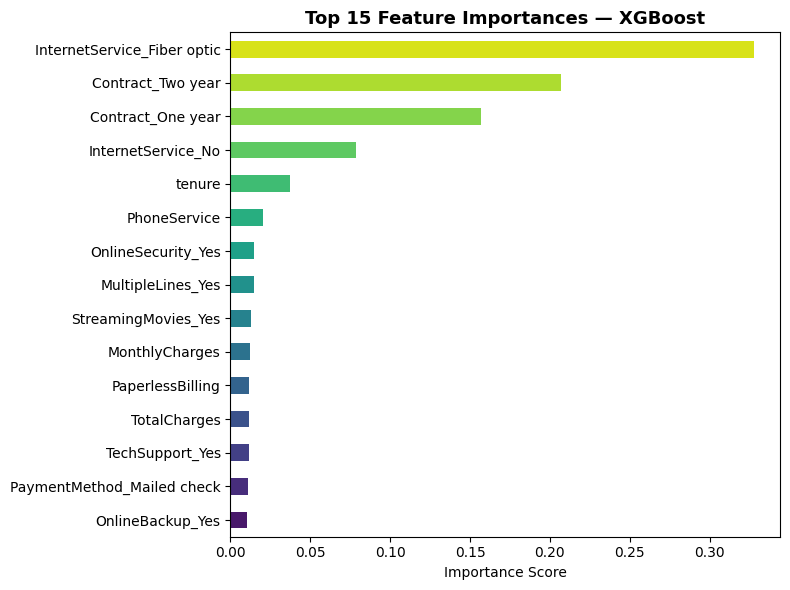

In [16]:
# Feature importances (best tree model)
best_tree = max({k:v for k,v in results.items() if k != "Logistic Regression"},
                key=lambda k: results[k]["auc"])
importances = pd.Series(results[best_tree]["model"].feature_importances_,
                         index=X.columns).nlargest(15)

fig, ax = plt.subplots(figsize=(8,6))
importances[::-1].plot.barh(ax=ax, color=sns.color_palette("viridis", len(importances)))
ax.set_title(f"Top 15 Feature Importances — {best_tree}", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot_feature_importance.png")
plt.show()

## Customer Risk Segmentation

In [17]:
df['churn_prob'] = model.predict_proba(X)[:, 1]

def segment_customer(prob):
    if prob >= 0.6:
        return 'High Risk'
    elif prob >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_segment'] = df['churn_prob'].apply(segment_customer)

In [18]:
df.groupby('risk_segment')['Churn'].mean()

risk_segment
High Risk      0.810714
Low Risk       0.073053
Medium Risk    0.470270
Name: Churn, dtype: float64

### Recommended action plan

In [19]:
action_map = {
    'High Risk': 'Offer discount + retention call',
    'Medium Risk': 'Email engagement campaign',
    'Low Risk': 'Upsell premium services'
}

df['recommended_action'] = df['risk_segment'].map(action_map)

To add more context, high-risk customers are significantly more likely to churn and should be prioritized for retention strategies. If the high risk belongs to month-to-month services then we can offer them heavy discounts without majorly reducing our bottom line.

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_prob,risk_segment,recommended_action
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0.724190,High Risk,Offer discount + retention call
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,0.036335,Low Risk,Upsell premium services
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.363748,Medium Risk,Email engagement campaign
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0.033282,Low Risk,Upsell premium services
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0.626952,High Risk,Offer discount + retention call


In [21]:
df[['Contract', 'tenure', 'PaymentMethod', 'MonthlyCharges', 'churn_prob', 'risk_segment', 'recommended_action']].head(20)

,Contract,tenure,PaymentMethod,MonthlyCharges,churn_prob,risk_segment,recommended_action
0,Month-to-month,1,Electronic check,29.85,0.724190,High Risk,Offer discount + retention call
1,One year,34,Mailed check,56.95,0.036335,Low Risk,Upsell premium services
2,Month-to-month,2,Mailed check,53.85,0.363748,Medium Risk,Email engagement campaign
3,One year,45,Bank transfer (automatic),42.30,0.033282,Low Risk,Upsell premium services
4,Month-to-month,2,Electronic check,70.70,0.626952,High Risk,Offer discount + retention call
5,Month-to-month,8,Electronic check,99.65,0.813238,High Risk,Offer discount + retention call
6,Month-to-month,22,Credit card (automatic),89.10,0.403603,Medium Risk,Email engagement campaign
7,Month-to-month,10,Mailed check,29.75,0.259064,Low Risk,Upsell premium services
8,Month-to-month,28,Electronic check,104.80,0.440868,Medium Risk,Email engagement campaign
9,One year,62,Bank transfer (automatic),56.15,0.028031,Low Risk,Upsell premium services


### Key Drivers of Churn

- Month-to-month contracts increase churn risk  
- Short tenure customers are more likely to leave  
- High monthly charges contribute to churn  

These insights enable targeted retention strategies.

## Business Recommendations

Based on model insights:

1. Convert month-to-month users to long-term contracts  
2. Target new users with onboarding programs  
3. Offer discounts to high-charge customers 

## Next Step: Recommendation System Integration

## Conclusion

This project demonstrates how machine learning can move beyond prediction to actionable business insights by combining:

- Churn prediction  
- Customer segmentation  
- Explainable AI  

The result is a system that supports real-world decision-making in SaaS environments.